# [Day 2 종합실습] NYC Yellow Taxi — 데이터 준비 + EDA

NYC Yellow Taxi 2026-05 trip 데이터를 Pandas/Polars 양쪽으로 로딩해 결과를 비교하고,  
원본 데이터를 그대로(정제 없이) 기본 EDA 및 시각화한다.

---
**실행 순서**: 위에서 아래로 셀을 순서대로 실행 (`Run All` 또는 `Shift+Enter`)  
**데이터**: 원본 URL에서 자동 다운로드 → `data/` 폴더에 캐시 저장 (이미 있으면 스킵)  
**결과물**: `output/` 폴더에 시각화 PNG 저장

| Part | 내용 |
|------|------|
| 1 | 환경 설정 및 함수 정의 |
| 2 | 데이터 로딩 — Pandas vs Polars 비교 |
| 4 | Zone 매핑 + py 기본 EDA 재현 |
| 5 | 결측치 & 데이터 품질 이슈 시각화 |
| 6 | 데이터 미리보기 (head / tail / sample) |
| 7 | 컬럼 타입 자동 분류 |
| 8 | 기술통계 — describe(include=all) |
| 9 | 범주형 변수 종합 분석 |
| 10 | 수치형 왜도/첨도 분석 |
| 11 | 수치형 분포 — 히스토그램 + KDE |
| 12 | 수치형 이상치 — 박스플롯 |
| 13 | 수치형 vs 수치형 — 상관관계 히트맵 |
| 14 | 수치형 vs 수치형 — 산점도 |
| 15 | 수치형 vs 범주형 — 그룹별 박스플롯 |
| 16 | 핵심 인사이트 시각화 |
| 17 | Borough 위치 분석 |
| 18 | 관찰 정리 + 팀원 인계 메모 |

---
## Part 1. 환경 설정 및 함수 정의

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "kaleido", "missingno"], check=True)
print("kaleido, missingno 설치 완료")

kaleido, missingno 설치 완료


In [2]:
from __future__ import annotations
import math, platform, sys, timeit, urllib.request
from pathlib import Path
from typing import Callable
from urllib.error import URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import polars as pl
import seaborn as sns
import missingno as msno
from plotly.subplots import make_subplots

import matplotlib.font_manager as fm

if platform.system() == "Darwin":
    # 폰트 캐시에서 AppleGothic 직접 경로 찾기
    font_list = [f.name for f in fm.fontManager.ttflist]
    if "AppleGothic" in font_list:
        plt.rcParams["font.family"] = "AppleGothic"
        PLOTLY_FONT = "AppleGothic"
    else:
        # AppleGothic 없으면 나눔고딕 시도
        plt.rcParams["font.family"] = "NanumGothic"
        PLOTLY_FONT = "NanumGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
    PLOTLY_FONT = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

# 폰트 캐시 강제 갱신
fm._load_fontmanager(try_read_cache=False)

print(f"설정된 폰트: {plt.rcParams['font.family']}")
print(f"사용 가능한 한글 폰트: {[f.name for f in fm.fontManager.ttflist if 'Gothic' in f.name or 'Nanum' in f.name]}")
# ── 경로 상수 ──
BASE_DIR         = Path(".").resolve()
DATA_DIR         = BASE_DIR / "data"
OUTPUT_DIR       = BASE_DIR / "output"
RAW_PATH         = DATA_DIR / "yellow_tripdata_2026-05.parquet"
ZONE_LOOKUP_PATH = DATA_DIR / "taxi_zone_lookup.csv"

DATA_URL        = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-05.parquet"
ZONE_LOOKUP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

NULLABLE_COLUMNS = ["passenger_count", "RatecodeID", "store_and_fwd_flag",
                    "congestion_surcharge", "Airport_fee"]
BENCHMARK_NUMBER = 3

# ── 범주형 라벨 매핑 ──
LABEL_MAP = {
    "payment_type"      : {1:"신용카드", 2:"현금", 3:"무료", 4:"분쟁", 5:"미상", 6:"취소"},
    "VendorID"          : {1:"CMT", 2:"VeriFone"},
    "RatecodeID"        : {1:"표준", 2:"JFK고정", 3:"Newark", 4:"Nassau",
                           5:"협상", 6:"그룹", 99:"기타"},
    "store_and_fwd_flag": {"Y":"오프라인→전송", "N":"실시간전송"},
}

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"BASE_DIR: {BASE_DIR}")
print(f"OS: {platform.system()} | 폰트: {PLOTLY_FONT}")

Matplotlib is building the font cache; this may take a moment.


설정된 폰트: ['AppleGothic']
사용 가능한 한글 폰트: ['Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', 'Apple SD Gothic Neo', '.Apple SD Gothic NeoI', '.Hiragino Kaku Gothic Interface', '.Hiragino Kaku Gothic Interface', '.Hiragino Kaku Gothic Interface', 'Hiragino Kaku Gothic ProN', 'Hiragino Kaku Gothic ProN W3', 'Hiragino Kaku Gothic Pro', 'Hiragino Kaku Gothic Pro W3', '.Hiragino Kaku Gothic Interface', '.Hiragino Kaku Gothic Interface', '.Hiragino Kaku Gothic Interface', 'AppleGothic', 'Nanum Gothic', 'NanumGothic', 'Nanum Gothic', 'NanumGothic', 'Nanum Gothic', 'NanumGothic', 'NanumGothic ExtraBold', 'Noto Sans Gothic', '.Hiragino Kaku Gothic Interface', '.Hiragino 

In [3]:
def print_title(title: str) -> None:
    print(f"\n{'='*70}\n{title}\n{'='*70}")

def benchmark(name: str, fn: Callable) -> dict:
    secs = timeit.timeit(fn, number=BENCHMARK_NUMBER)
    return {"tool": name, "seconds": secs / BENCHMARK_NUMBER}

def ensure_raw_data() -> Path:
    if not RAW_PATH.exists():
        print(f"다운로드 중: {DATA_URL}")
        try:
            urllib.request.urlretrieve(DATA_URL, RAW_PATH)
            print("완료")
        except (URLError, OSError, TimeoutError) as e:
            raise RuntimeError(f"다운로드 실패: {e}") from e
    else:
        print(f"캐시 사용: {RAW_PATH}")
    return RAW_PATH

def ensure_zone_lookup() -> Path:
    if not ZONE_LOOKUP_PATH.exists():
        print(f"다운로드 중: {ZONE_LOOKUP_URL}")
        try:
            urllib.request.urlretrieve(ZONE_LOOKUP_URL, ZONE_LOOKUP_PATH)
            print("완료")
        except (URLError, OSError, TimeoutError) as e:
            raise RuntimeError(f"다운로드 실패: {e}") from e
    else:
        print(f"캐시 사용: {ZONE_LOOKUP_PATH}")
    return ZONE_LOOKUP_PATH

def load_with_pandas(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path)

def load_with_polars(path: Path) -> pl.DataFrame:
    return pl.read_parquet(path)

def save_fig(fig_obj, filename: str) -> None:
    out = OUTPUT_DIR / filename
    if isinstance(fig_obj, plt.Figure):
        fig_obj.savefig(out, dpi=150, bbox_inches="tight")
    else:
        fig_obj.write_image(str(out), scale=2)
    print(f"저장: {out}")

print("함수 정의 완료")

함수 정의 완료


---
## Part 2. 데이터 로딩 — Pandas vs Polars 비교

In [4]:
raw_path = ensure_raw_data()
pdf  = load_with_pandas(raw_path)
pldf = load_with_polars(raw_path)

print_title("1. Pandas vs Polars 로딩 결과 비교")
print(f"Pandas shape : {pdf.shape}")
print(f"Polars shape : {pldf.shape}")
print(f"행 수 일치   : {pdf.shape[0] == pldf.shape[0]}")

pandas_na = pdf[NULLABLE_COLUMNS].isna().sum()
polars_na = pldf.select(NULLABLE_COLUMNS).null_count()
print("\n[컬럼별 결측치 수 비교]")
for col in NULLABLE_COLUMNS:
    p, pl_ = int(pandas_na[col]), int(polars_na[col][0])
    print(f"  {col:22s} Pandas={p:8,d}  Polars={pl_:8,d}  일치={p==pl_}")

print(f"\n[로딩 속도 비교 ({BENCHMARK_NUMBER}회 평균)]")
for r in sorted([
    benchmark("Pandas", lambda: load_with_pandas(raw_path)),
    benchmark("Polars", lambda: load_with_polars(raw_path)),
], key=lambda x: x["seconds"]):
    print(f"  {r['tool']:8s} 평균 {r['seconds']:.3f} s")

캐시 사용: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/data/yellow_tripdata_2026-05.parquet



1. Pandas vs Polars 로딩 결과 비교
Pandas shape : (4090836, 20)
Polars shape : (4090836, 20)
행 수 일치   : True

[컬럼별 결측치 수 비교]
  passenger_count        Pandas= 955,371  Polars= 955,371  일치=True
  RatecodeID             Pandas= 955,371  Polars= 955,371  일치=True
  store_and_fwd_flag     Pandas= 955,371  Polars= 955,371  일치=True
  congestion_surcharge   Pandas= 955,371  Polars= 955,371  일치=True
  Airport_fee            Pandas= 955,371  Polars= 955,371  일치=True

[로딩 속도 비교 (3회 평균)]


  Polars   평균 0.065 s
  Pandas   평균 0.125 s


---
## Part 4. Zone 매핑 + py 기본 EDA 재현


3. 기본 EDA (py 원본)
shape: (4090836, 20)

[수치형 기술통계]


       trip_distance   fare_amount    tip_amount  total_amount
count   4.090836e+06  4.090836e+06  4.090836e+06  4.090836e+06
mean    4.954773e+00  2.151320e+01  2.976733e+00  3.048514e+01
std     4.836157e+02  1.901303e+01  4.015296e+00  2.297497e+01
min     0.000000e+00 -9.500000e+02 -4.710000e+01 -9.510000e+02
25%     1.040000e+00  1.000000e+01  0.000000e+00  1.764000e+01
50%     1.870000e+00  1.630000e+01  2.240000e+00  2.394000e+01
75%     3.810000e+00  2.680000e+01  4.100000e+00  3.495000e+01
max     3.074915e+05  5.525990e+03  2.390000e+02  5.530740e+03

[payment_type 분포]
payment_type
0     955371
1    2727585
2     372909
3      11984
4      22987
Name: count, dtype: int64

[소요시간] 평균 18.8분, 중앙값 14.5분
소요시간 0분 이하: 52,063건

[total_amount IQR 이상치] [-8.33, 60.92]
이상치 365,265건 (8.9%) | 음수 14,877건
캐시 사용: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/data/taxi_zone_lookup.csv



4. 위치(Zone) 매핑
                 trips   avg_total
PU_Borough                        
Manhattan      3537655   26.497792
Queens          351348   67.191280
Brooklyn        158842   35.223229
Bronx            35669   37.381920
Unknown           4734   36.831464
EWR                504  113.704286
Staten Island      332   49.641928

[픽업 Zone 상위 10]
 PU_Zone
Upper East Side South           198008
Upper East Side North           175969
Midtown Center                  161315
JFK Airport                     149312
Lincoln Square East             124523
Midtown East                    120488
Penn Station/Madison Sq West    113921
Times Sq/Theatre District       111934
Upper West Side South           108689
East Village                    107374
Name: count, dtype: int64


저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/00_top_zones_py_original.png


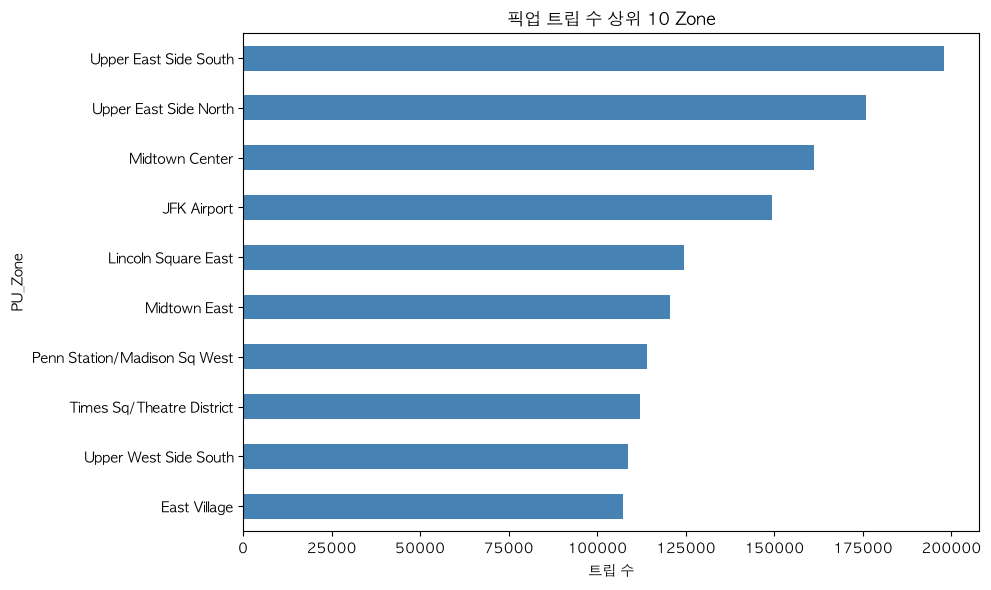

In [5]:
def run_basic_eda(df: pd.DataFrame) -> None:
    print_title("3. 기본 EDA (py 원본)")
    print(f"shape: {df.shape}")
    print("\n[수치형 기술통계]")
    print(df[["trip_distance","fare_amount","tip_amount","total_amount"]].describe())
    print("\n[payment_type 분포]")
    print(df["payment_type"].value_counts().sort_index())
    dur = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds()/60
    print(f"\n[소요시간] 평균 {dur.mean():.1f}분, 중앙값 {dur.median():.1f}분")
    print(f"소요시간 0분 이하: {(dur<=0).sum():,}건")
    q1, q3 = df["total_amount"].quantile(0.25), df["total_amount"].quantile(0.75)
    iqr = q3-q1; lo, hi = q1-1.5*iqr, q3+1.5*iqr
    out = ~df["total_amount"].between(lo,hi)
    print(f"\n[total_amount IQR 이상치] [{lo:.2f}, {hi:.2f}]")
    print(f"이상치 {out.sum():,}건 ({out.mean()*100:.1f}%) | 음수 {(df['total_amount']<0).sum():,}건")

def map_location_names(df: pd.DataFrame, zone_lookup: pd.DataFrame) -> pd.DataFrame:
    lookup = zone_lookup.set_index("LocationID")[["Borough","Zone"]]
    result = df.join(lookup.add_prefix("PU_"), on="PULocationID")
    return result.join(lookup.add_prefix("DO_"), on="DOLocationID")

def show_location_map(df: pd.DataFrame) -> None:
    print_title("4. 위치(Zone) 매핑")
    bs = (df.groupby("PU_Borough",observed=True)
          .agg(trips=("total_amount","count"),avg_total=("total_amount","mean"))
          .sort_values("trips",ascending=False))
    print(bs)
    top = df["PU_Zone"].value_counts().head(10)
    print("\n[픽업 Zone 상위 10]\n", top)
    fig, ax = plt.subplots(figsize=(10,6))
    top.sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("픽업 트립 수 상위 10 Zone")
    ax.set_xlabel("트립 수")
    plt.tight_layout()
    save_fig(fig, "00_top_zones_py_original.png")
    plt.show(); plt.close(fig)

run_basic_eda(pdf)
zone_lookup = pd.read_csv(ensure_zone_lookup())
mapped = map_location_names(pdf, zone_lookup)
show_location_map(mapped)

---
## Part 5. 결측치 & 데이터 품질 이슈 시각화
> 원본 데이터를 정제하기 전에, 어떤 이슈가 있는지 먼저 시각적으로 파악한다.


5-A. 결측치 시각화 (missingno)


저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/05a_missing_matrix.png


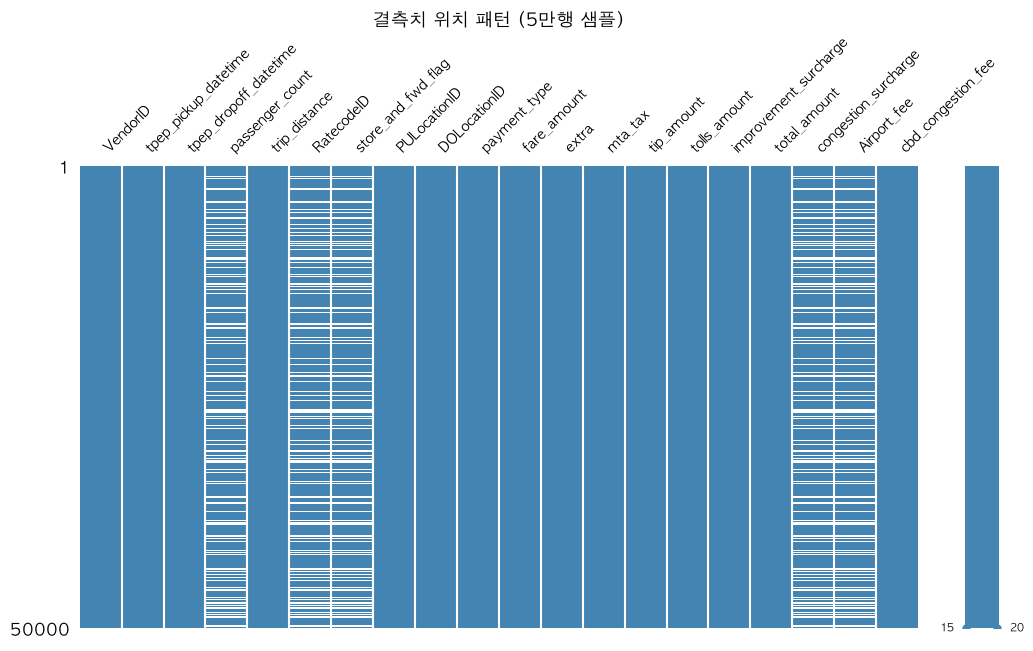

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/05a_missing_bar.png


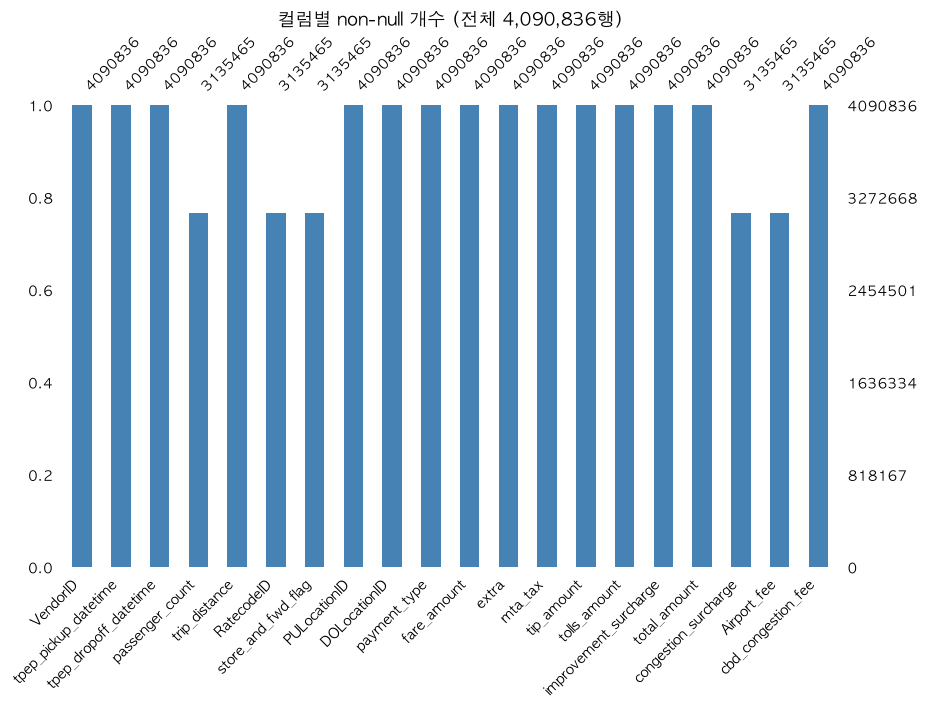

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/05a_missing_heatmap.png


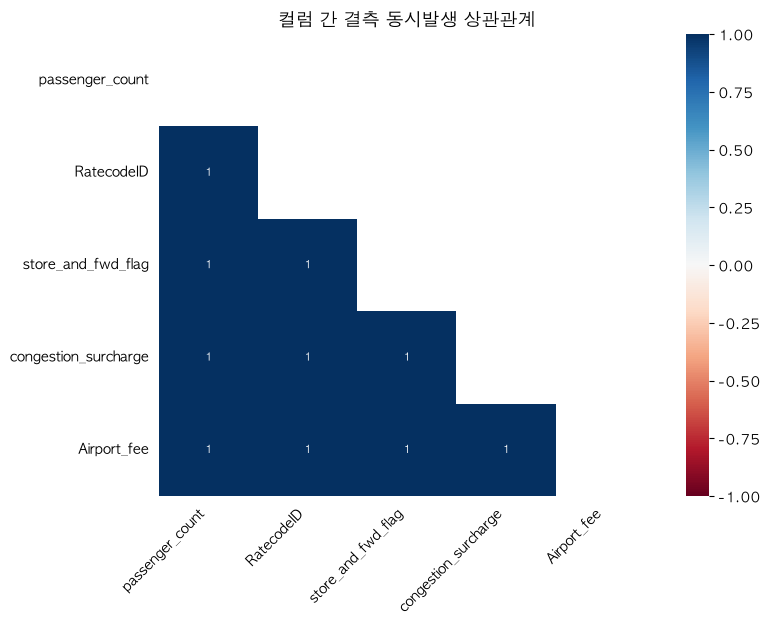


결측치 있는 컬럼 (5개): ['passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', 'Airport_fee']
  passenger_count         955,371건 (23.35%)
  RatecodeID              955,371건 (23.35%)
  store_and_fwd_flag      955,371건 (23.35%)
  congestion_surcharge    955,371건 (23.35%)
  Airport_fee             955,371건 (23.35%)

[강의자료 Think to look for — 결측치]
  ✓ 5개 컬럼 결측 건수가 전부 동일 → heatmap 상관계수가 1이면 같은 행에서 함께 비어있다는 뜻
  ✓ 무작위 결측(MCAR)인지, 특정 조건(벤더/기간 등)에 몰린 결측인지 원인 파악 필요


In [6]:
print_title("5-A. 결측치 시각화 (missingno)")

# matrix는 행 단위로 그려서 4백만 행 그대로 그리면 매우 느림 → 패턴 확인용으로 샘플링
msno_sample = pdf.sample(50_000, random_state=42)

ax_matrix = msno.matrix(msno_sample, figsize=(12, 6), fontsize=10,
                         color=(0.27, 0.52, 0.70))  # steelblue 톤
ax_matrix.set_title("결측치 위치 패턴 (5만행 샘플)", fontsize=13)
save_fig(ax_matrix.get_figure(), "05a_missing_matrix.png")
plt.show(); plt.close(ax_matrix.get_figure())

ax_bar = msno.bar(pdf, figsize=(10, 6), fontsize=10, color="steelblue")
ax_bar.set_title(f"컬럼별 non-null 개수 (전체 {len(pdf):,}행)", fontsize=13)
save_fig(ax_bar.get_figure(), "05a_missing_bar.png")
plt.show(); plt.close(ax_bar.get_figure())

ax_heatmap = msno.heatmap(pdf, figsize=(8, 6), fontsize=10, cmap="RdBu")
ax_heatmap.set_title("컬럼 간 결측 동시발생 상관관계", fontsize=13)
save_fig(ax_heatmap.get_figure(), "05a_missing_heatmap.png")
plt.show(); plt.close(ax_heatmap.get_figure())

na_counts = pdf[NULLABLE_COLUMNS].isna().sum()
print(f"\n결측치 있는 컬럼 ({len(NULLABLE_COLUMNS)}개): {NULLABLE_COLUMNS}")
for col, n in na_counts.items():
    print(f"  {col:22s} {n:8,d}건 ({n/len(pdf)*100:.2f}%)")

print("\n[강의자료 Think to look for — 결측치]")
print("  ✓ 5개 컬럼 결측 건수가 전부 동일 → heatmap 상관계수가 1이면 같은 행에서 함께 비어있다는 뜻")
print("  ✓ 무작위 결측(MCAR)인지, 특정 조건(벤더/기간 등)에 몰린 결측인지 원인 파악 필요")


5-B. 정제 전 데이터 품질 이슈 요약


저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/05b_data_quality_issues.png


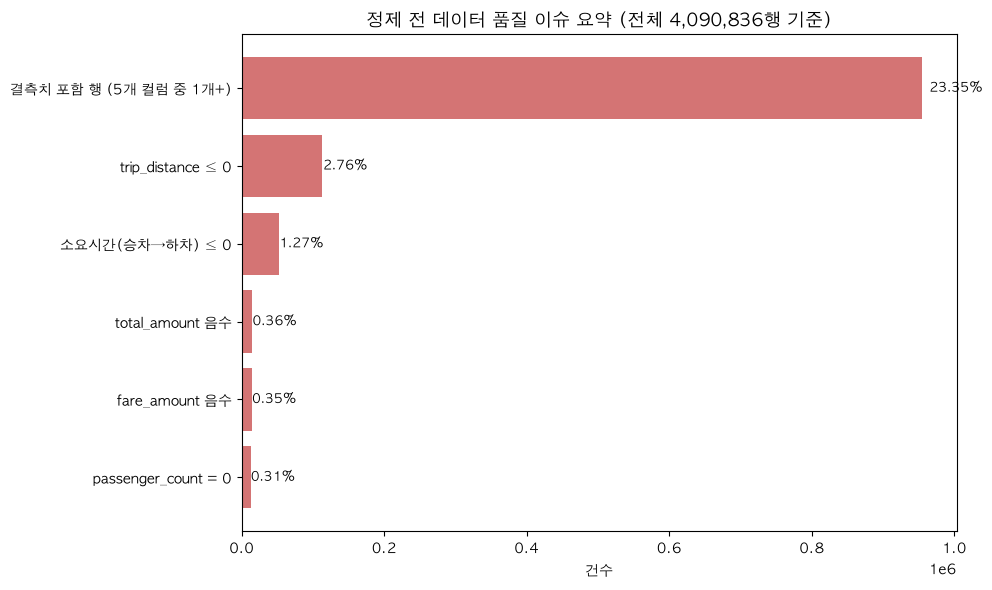

,건수,비율(%)
이슈,,
passenger_count = 0,12533,0.31
fare_amount 음수,14231,0.35
total_amount 음수,14877,0.36
소요시간(승차→하차) ≤ 0,52063,1.27
trip_distance ≤ 0,113031,2.76
결측치 포함 행 (5개 컬럼 중 1개+),955371,23.35



[강의자료 Think to look for — 데이터 품질]
  ✓ 음수 금액/거리/소요시간은 입력 오류 또는 취소·환불 케이스일 가능성
  ✓ 결측치 5종은 함께 발생 → 별도 대체(중앙값/최빈값) 전략보다 원인 확인이 우선
  → 이 요약이 곧 정제(Part 3) 단계에서 처리해야 할 항목 목록


In [7]:
print_title("5-B. 정제 전 데이터 품질 이슈 요약")

dur_min = (pdf["tpep_dropoff_datetime"] - pdf["tpep_pickup_datetime"]).dt.total_seconds() / 60

issues = {
    "결측치 포함 행 (5개 컬럼 중 1개+)": pdf[NULLABLE_COLUMNS].isna().any(axis=1).sum(),
    "total_amount 음수"              : (pdf["total_amount"] < 0).sum(),
    "fare_amount 음수"               : (pdf["fare_amount"] < 0).sum(),
    "trip_distance ≤ 0"              : (pdf["trip_distance"] <= 0).sum(),
    "소요시간(승차→하차) ≤ 0"          : (dur_min <= 0).sum(),
    "passenger_count = 0"            : (pdf["passenger_count"] == 0).sum(),
}
issue_df = pd.DataFrame({"이슈": list(issues.keys()), "건수": list(issues.values())})
issue_df["비율(%)"] = (issue_df["건수"] / len(pdf) * 100).round(2)
issue_df = issue_df.sort_values("건수")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(issue_df["이슈"], issue_df["건수"], color="indianred", alpha=0.85)
for bar, pct in zip(bars, issue_df["비율(%)"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=9)
ax.set_title(f"정제 전 데이터 품질 이슈 요약 (전체 {len(pdf):,}행 기준)", fontsize=13)
ax.set_xlabel("건수")
plt.tight_layout()
save_fig(fig, "05b_data_quality_issues.png")
plt.show(); plt.close(fig)

display(issue_df.set_index("이슈"))

print("\n[강의자료 Think to look for — 데이터 품질]")
print("  ✓ 음수 금액/거리/소요시간은 입력 오류 또는 취소·환불 케이스일 가능성")
print("  ✓ 결측치 5종은 함께 발생 → 별도 대체(중앙값/최빈값) 전략보다 원인 확인이 우선")
print("  → 이 요약이 곧 정제(Part 3) 단계에서 처리해야 할 항목 목록")

---
## Part 6. 데이터 미리보기 (head / tail / sample)
> 강의자료 EDA Checklist p.17~18

In [8]:
print_title("6. 데이터 미리보기")
print("\n[head(5)] — 처음 5행")
display(pdf.head(5))
print("\n[tail(5)] — 마지막 5행")
display(pdf.tail(5))
print("\n[sample(5, random_state=42)] — 무작위 5행")
display(pdf.sample(5, random_state=42))


6. 데이터 미리보기

[head(5)] — 처음 5행


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,35.9,6.00,0.5,0.00,0.0,1.0,45.40,0.0,2.0,0.00
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,27.5,6.00,0.5,9.56,0.0,1.0,49.81,2.5,2.0,0.75
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,19.1,4.25,0.5,3.73,0.0,1.0,28.58,2.5,0.0,0.75
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.20,1.0,N,232,114,1,9.3,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75
4,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,7.2,0.00,0.5,2.44,0.0,1.0,14.64,2.5,0.0,0.00



[tail(5)] — 마지막 5행


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
4090831,2,2026-05-31 23:35:12,2026-05-31 23:51:04,NaN,5.11,NaN,None,74,243,0,17.19,0.0,0.5,0.0,0.0,1.0,18.69,NaN,NaN,0.00
4090832,1,2026-05-31 23:48:01,2026-06-01 00:05:57,NaN,8.80,NaN,None,129,130,0,27.98,0.0,0.5,0.0,0.0,1.0,33.48,NaN,NaN,0.00
4090833,2,2026-05-31 23:48:50,2026-06-01 00:03:52,NaN,6.47,NaN,None,48,116,0,24.12,0.0,0.5,0.0,0.0,1.0,28.87,NaN,NaN,0.75
4090834,2,2026-05-31 23:23:13,2026-05-31 23:38:35,NaN,2.94,NaN,None,113,256,0,18.20,0.0,0.5,0.0,0.0,1.0,22.95,NaN,NaN,0.75
4090835,2,2026-05-31 23:41:51,2026-05-31 23:47:32,NaN,0.83,NaN,None,255,112,0,7.02,0.0,0.5,0.0,0.0,1.0,8.52,NaN,NaN,0.00



[sample(5, random_state=42)] — 무작위 5행


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
182196,2,2026-05-02 18:03:26,2026-05-02 18:08:58,1.0,1.07,1.0,N,236,239,1,7.90,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0,0.00
912818,2,2026-05-09 18:17:34,2026-05-09 18:50:28,1.0,4.94,1.0,N,231,142,1,32.40,0.0,0.5,7.43,0.0,1.0,44.58,2.5,0.0,0.75
53506,2,2026-05-01 15:54:42,2026-05-01 16:06:35,1.0,1.44,1.0,N,170,141,1,12.10,0.0,0.5,0.00,0.0,1.0,16.85,2.5,0.0,0.75
3844399,2,2026-05-23 23:02:41,2026-05-23 23:23:02,NaN,3.54,NaN,None,234,239,0,26.18,0.0,0.5,0.00,0.0,1.0,30.93,NaN,NaN,0.75
2253303,1,2026-05-22 07:12:39,2026-05-22 07:51:05,1.0,34.90,99.0,N,236,244,1,28.50,0.0,0.5,0.00,0.0,0.0,29.00,0.0,0.0,0.00


---
## Part 7. 컬럼 타입 자동 분류

In [9]:
ID_LIKE_COLS  = {"VendorID","PULocationID","DOLocationID",
                 "payment_type","RatecodeID","passenger_count"}
DATETIME_COLS = [c for c in pdf.columns
                 if pd.api.types.is_datetime64_any_dtype(pdf[c])]
LOCATION_COLS = ["PULocationID","DOLocationID"]

numeric_cols = [
    c for c in pdf.select_dtypes(include=["number"]).columns
    if c not in ID_LIKE_COLS
]
categorical_cols = (
    list(pdf.select_dtypes(include=["object","category"]).columns)
    + [c for c in ID_LIKE_COLS if c in pdf.columns and c not in LOCATION_COLS]
)
categorical_cols = list(dict.fromkeys(categorical_cols))

print_title("7. 컬럼 타입 분류 결과")
print(f"\n■ 수치형   ({len(numeric_cols)}개): {numeric_cols}")
print(f"\n■ 범주형   ({len(categorical_cols)}개): {categorical_cols}")
print(f"\n■ 날짜형   ({len(DATETIME_COLS)}개): {DATETIME_COLS}")
print(f"\n■ 위치코드 ({len(LOCATION_COLS)}개): {LOCATION_COLS}")
print(f"\n전체 컬럼 수: {pdf.shape[1]}개")


7. 컬럼 타입 분류 결과

■ 수치형   (11개): ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

■ 범주형   (5개): ['store_and_fwd_flag', 'payment_type', 'RatecodeID', 'passenger_count', 'VendorID']

■ 날짜형   (2개): ['tpep_pickup_datetime', 'tpep_dropoff_datetime']

■ 위치코드 (2개): ['PULocationID', 'DOLocationID']

전체 컬럼 수: 20개


---
## Part 8. 기술통계 — describe(include='all')
> 강의자료 p.19 — 수치형 + 범주형 전체 요약

In [10]:
print_title("8-A. 수치형 기술통계")
display(
    pdf[numeric_cols].describe().T
    .style.format("{:.3f}")
    .background_gradient(cmap="Blues", axis=0)
)


8-A. 수치형 기술통계


,count,mean,std,min,25%,50%,75%,max
trip_distance,4090836.000,4.955,483.616,0.000,1.040,1.870,3.810,307491.470
fare_amount,4090836.000,21.513,19.013,-950.000,10.000,16.300,26.800,5525.990
extra,4090836.000,1.123,1.751,-7.500,0.000,0.000,2.500,15.250
mta_tax,4090836.000,0.490,0.081,-0.500,0.500,0.500,0.500,4.750
tip_amount,4090836.000,2.977,4.015,-47.100,0.000,2.240,4.100,239.000
tolls_amount,4090836.000,0.537,2.178,-51.000,0.000,0.000,0.000,145.600
improvement_surcharge,4090836.000,0.957,0.219,-1.000,1.000,1.000,1.000,2.500
total_amount,4090836.000,30.485,22.975,-951.000,17.640,23.940,34.950,5530.740
congestion_surcharge,3135465.000,2.203,0.838,-2.500,2.500,2.500,2.500,2.500
Airport_fee,3135465.000,0.165,0.591,-2.000,0.000,0.000,0.000,27.000


In [11]:
print_title("8-B. 전체 기술통계 describe(include='all')")
display(pdf.describe(include="all"))


8-B. 전체 기술통계 describe(include='all')


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,4.090836e+06,4090836,4090836,3.135465e+06,4.090836e+06,3.135465e+06,3135465,4.090836e+06,4.090836e+06,4.090836e+06,4.090836e+06,4.090836e+06,4.090836e+06,4.090836e+06,4.090836e+06,4.090836e+06,4.090836e+06,3.135465e+06,3.135465e+06,4.090836e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,3131868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.873889e+00,2026-05-16 10:34:13.127794,2026-05-16 10:52:59.680849,1.243260e+00,4.954773e+00,5.495495e+00,NaN,1.621047e+02,1.618326e+02,8.803342e-01,2.151320e+01,1.123163e+00,4.901416e-01,2.976733e+00,5.369256e-01,9.568193e-01,3.048514e+01,2.203066e+00,1.646423e-01,4.935183e-01
min,1.000000e+00,2008-12-31 23:05:53,2009-01-01 17:08:07,0.000000e+00,0.000000e+00,1.000000e+00,NaN,1.000000e+00,1.000000e+00,0.000000e+00,-9.500000e+02,-7.500000e+00,-5.000000e-01,-4.710000e+01,-5.100000e+01,-1.000000e+00,-9.510000e+02,-2.500000e+00,-2.000000e+00,-7.500000e-01
25%,2.000000e+00,2026-05-08 21:15:44.750000,2026-05-08 21:32:40.500000,1.000000e+00,1.040000e+00,1.000000e+00,NaN,1.140000e+02,1.080000e+02,1.000000e+00,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.764000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2026-05-16 01:47:51,2026-05-16 02:03:14.500000,1.000000e+00,1.870000e+00,1.000000e+00,NaN,1.610000e+02,1.620000e+02,1.000000e+00,1.630000e+01,0.000000e+00,5.000000e-01,2.240000e+00,0.000000e+00,1.000000e+00,2.394000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2026-05-23 15:40:14.250000,2026-05-23 15:57:52.250000,1.000000e+00,3.810000e+00,1.000000e+00,NaN,2.340000e+02,2.340000e+02,1.000000e+00,2.680000e+01,2.500000e+00,5.000000e-01,4.100000e+00,0.000000e+00,1.000000e+00,3.495000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2026-06-01 00:20:35,2026-06-02 12:53:42,9.000000e+00,3.074915e+05,9.900000e+01,NaN,2.650000e+02,2.650000e+02,4.000000e+00,5.525990e+03,1.525000e+01,4.750000e+00,2.390000e+02,1.456000e+02,2.500000e+00,5.530740e+03,2.500000e+00,2.700000e+01,7.500000e-01


---
## Part 9. 범주형 변수 종합 분석
> 강의자료 p.20 체크리스트: unique / nunique / value_counts / value_counts(normalize=True)
> 강의자료 p.27 시각화: Bar Chart

In [12]:
print_title("9-A. 범주형 변수 요약표")
rows = []
for col in categorical_cols:
    vc = pdf[col].value_counts()
    rows.append({
        "컬럼명"     : col,
        "dtype"      : str(pdf[col].dtype),
        "고유값 수"   : pdf[col].nunique(),
        "결측치"     : pdf[col].isnull().sum(),
        "최빈값"     : vc.index[0],
        "최빈값 비율" : f"{vc.iloc[0]/len(pdf)*100:.1f}%",
        "고유값 목록" : str(sorted(pdf[col].dropna().unique().tolist())),
    })
display(pd.DataFrame(rows).set_index("컬럼명"))


9-A. 범주형 변수 요약표


,dtype,고유값 수,결측치,최빈값,최빈값 비율,고유값 목록
컬럼명,,,,,,
store_and_fwd_flag,object,2,955371,N,76.6%,"['N', 'Y']"
payment_type,int64,5,0,1,66.7%,"[0, 1, 2, 3, 4]"
RatecodeID,float64,7,955371,1.0,69.5%,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0]"
passenger_count,float64,9,955371,1.0,63.0%,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 9.0]"
VendorID,int32,4,0,2,78.9%,"[1, 2, 6, 7]"


In [13]:
print_title("9-B. 컬럼별 unique / value_counts / 상대도수")
for col in categorical_cols:
    vc     = pdf[col].value_counts()
    vc_pct = pdf[col].value_counts(normalize=True).mul(100).round(2)
    detail = pd.DataFrame({"도수": vc, "비율(%)": vc_pct})
    if col in LABEL_MAP:
        detail.index = detail.index.map(
            lambda x: f"{x} ({LABEL_MAP[col].get(x,'?')})"
        )
    print(f"\n── {col}")
    print(f"   unique 값: {pdf[col].unique().tolist()}")
    display(detail)


9-B. 컬럼별 unique / value_counts / 상대도수

── store_and_fwd_flag
   unique 값: ['N', 'Y', None]


,도수,비율(%)
store_and_fwd_flag,,
N (실시간전송),3131868,99.89
Y (오프라인→전송),3597,0.11



── payment_type
   unique 값: [2, 1, 4, 3, 0]


,도수,비율(%)
payment_type,,
1 (신용카드),2727585,66.68
0 (?),955371,23.35
2 (현금),372909,9.12
4 (분쟁),22987,0.56
3 (무료),11984,0.29



── RatecodeID
   unique 값: [1.0, 2.0, 99.0, 5.0, 4.0, 3.0, 6.0, nan]


,도수,비율(%)
RatecodeID,,
1.0 (표준),2842930,90.67
99.0 (기타),140897,4.49
2.0 (JFK고정),95155,3.03
5.0 (협상),35523,1.13
3.0 (Newark),12567,0.40
4.0 (Nassau),8392,0.27
6.0 (그룹),1,0.00



── passenger_count
   unique 값: [1.0, 0.0, 2.0, 4.0, 5.0, 3.0, 6.0, 8.0, 9.0, nan]


,도수,비율(%)
passenger_count,,
1.0,2578718,82.24
2.0,395103,12.60
3.0,83959,2.68
4.0,52929,1.69
0.0,12533,0.40
5.0,7666,0.24
6.0,4553,0.15
8.0,3,0.00
9.0,1,0.00



── VendorID
   unique 값: [2, 1, 7, 6]


,도수,비율(%)
VendorID,,
2 (VeriFone),3226222,78.86
1 (CMT),805221,19.68
7 (?),51750,1.27
6 (?),7643,0.19



9-C. 범주형 분포 — Bar Chart (강의자료 p.27 권장)


/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn/T/ipykernel_88974/1855985970.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vc, x="label", y="count", ax=ax,
/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn/T/ipykernel_88974/1855985970.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vc, x="label", y="count", ax=ax,
/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn/T/ipykernel_88974/1855985970.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vc, x="label", y="count", ax=ax,
/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/09_categorical_bar.png


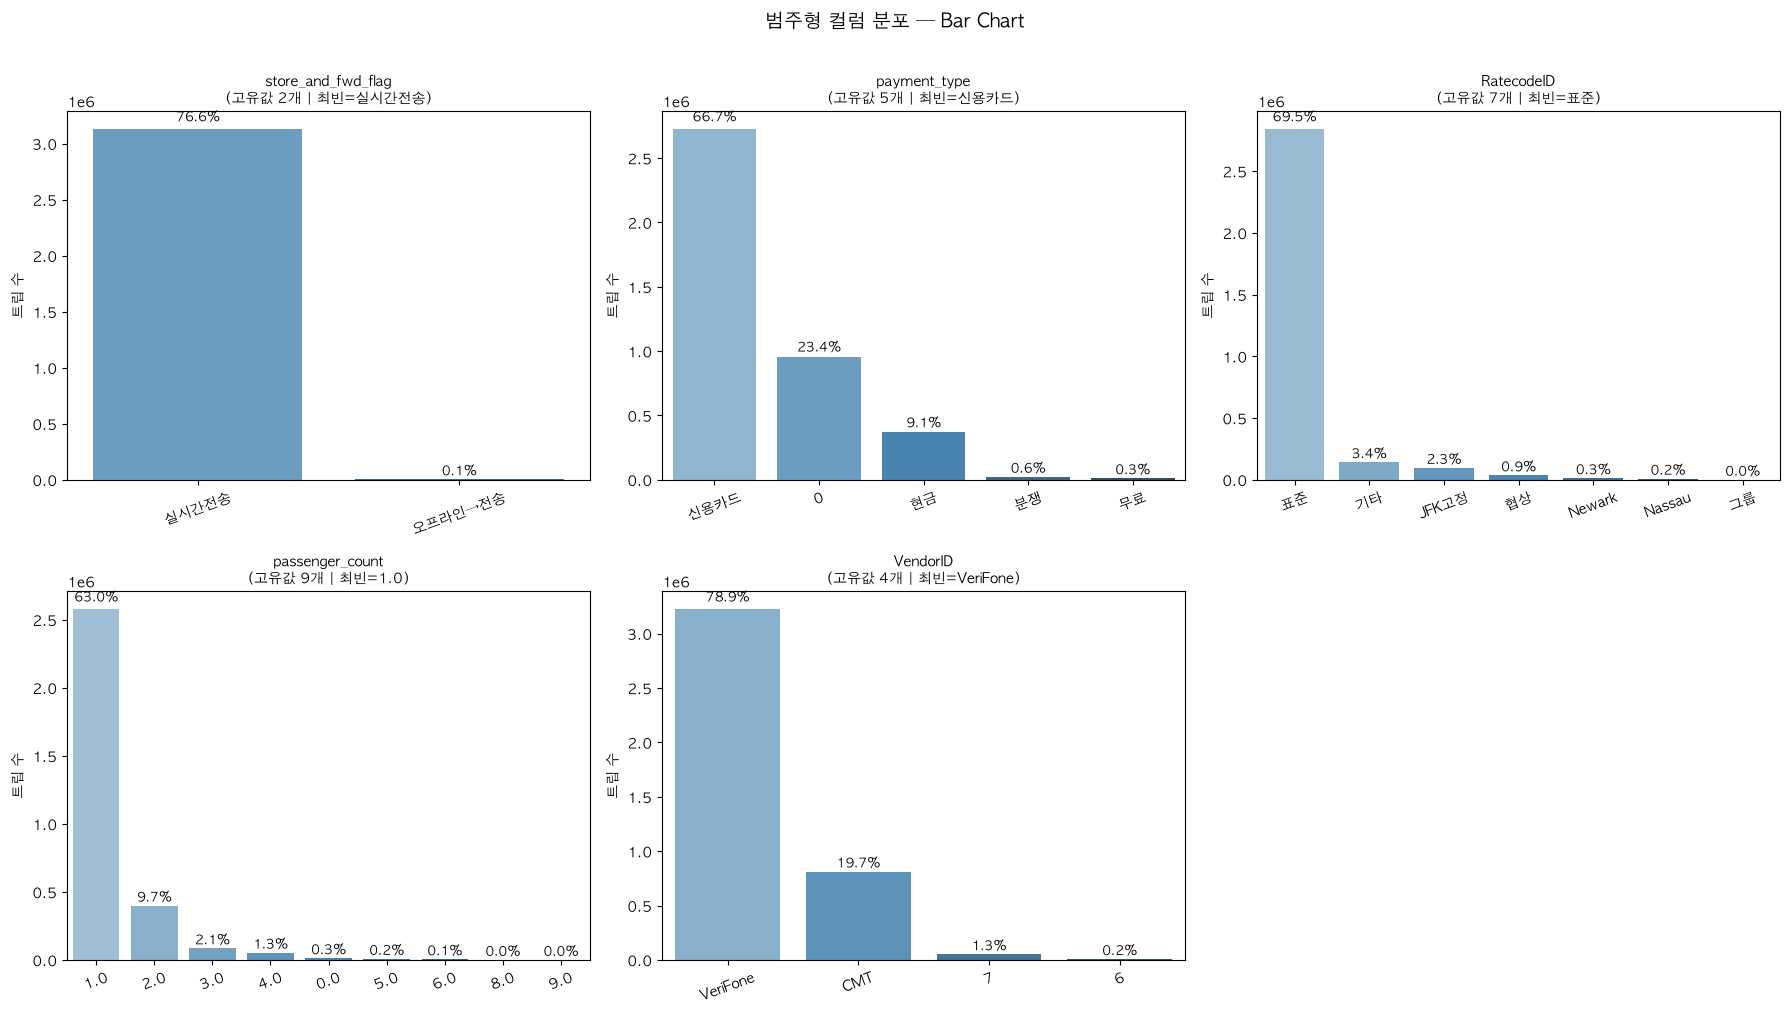


[강의자료 Think to look for — 범주형]
  ✓ High Cardinality 변수? (nunique ≈ 행 수 → Encoding 불가)
  ✓ 특정 값에 극단 치우침? → 클래스 불균형 주의
  ✓ 의미 없는 범주(Unknown 등)가 많은 비중?
  ⚠ store_and_fwd_flag: 최빈값 99.9% → 클래스 불균형 확인 필요
  ⚠ RatecodeID: 최빈값 90.7% → 클래스 불균형 확인 필요
  ⚠ passenger_count: 최빈값 82.2% → 클래스 불균형 확인 필요


In [14]:
print_title("9-C. 범주형 분포 — Bar Chart (강의자료 p.27 권장)")
n_c = 3; n_r = math.ceil(len(categorical_cols)/n_c)
fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r*5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    vc = pdf[col].value_counts().reset_index()
    vc.columns = [col, "count"]
    vc["pct"] = (vc["count"]/len(pdf)*100).round(1)
    vc["label"] = vc[col].map(LABEL_MAP.get(col,{})).fillna(vc[col].astype(str)) if col in LABEL_MAP else vc[col].astype(str)

    sns.barplot(data=vc, x="label", y="count", ax=ax,
                palette="Blues_d", order=vc["label"])
    for j, row in vc.iterrows():
        ax.text(j, row["count"]*1.01, f"{row['pct']}%",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{col}\n(고유값 {pdf[col].nunique()}개 | 최빈={vc.iloc[0]['label']})", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("트립 수")
    ax.tick_params(axis="x", rotation=20)

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
fig.suptitle("범주형 컬럼 분포 — Bar Chart", fontsize=14, y=1.01)
plt.tight_layout()
save_fig(fig, "09_categorical_bar.png")
plt.show(); plt.close(fig)

print("\n[강의자료 Think to look for — 범주형]")
print("  ✓ High Cardinality 변수? (nunique ≈ 행 수 → Encoding 불가)")
print("  ✓ 특정 값에 극단 치우침? → 클래스 불균형 주의")
print("  ✓ 의미 없는 범주(Unknown 등)가 많은 비중?")
for col in categorical_cols:
    top_pct = pdf[col].value_counts(normalize=True).iloc[0]*100
    if top_pct > 80:
        print(f"  ⚠ {col}: 최빈값 {top_pct:.1f}% → 클래스 불균형 확인 필요")

---
## Part 10. 수치형 — 왜도(Skewness) / 첨도(Kurtosis)
> 강의자료 p.15 Descriptive Statistics — 분포 형태 파악
> 왜도 |v|>1 → 로그변환 권장 (강의자료 p.57)

In [15]:
print_title("10. 수치형 왜도 / 첨도 분석")
skew = pdf[numeric_cols].skew()
kurt = pdf[numeric_cols].kurtosis()  # 초과첨도 (정규=0)

def skew_label(v):
    if abs(v) <= 0.5:   return "대칭 (변환 불필요)"
    elif abs(v) <= 1.0: return "약한 비대칭 (변환 고려)"
    else:               return "강한 비대칭 → 로그변환 권장"

def kurt_label(v):
    if v > 1:    return "뾰족 (이상치 많을 가능성)"
    elif v < -1: return "납작 (꼬리 얇음)"
    else:        return "정상 범위"

display(pd.DataFrame({
    "왜도(skewness)" : skew.round(3),
    "왜도 해석"      : skew.map(skew_label),
    "첨도(kurtosis)": kurt.round(3),
    "첨도 해석"      : kurt.map(kurt_label),
}))

log_cands = skew[skew.abs() > 1].index.tolist()
print(f"\n로그변환 권장 컬럼 ({len(log_cands)}개): {log_cands}")
print("→ np.log1p() 사용 (0 포함 데이터 대응)")


10. 수치형 왜도 / 첨도 분석


,왜도(skewness),왜도 해석,첨도(kurtosis),첨도 해석
trip_distance,386.619,강한 비대칭 → 로그변환 권장,171277.777,뾰족 (이상치 많을 가능성)
fare_amount,22.036,강한 비대칭 → 로그변환 권장,5314.836,뾰족 (이상치 많을 가능성)
extra,1.860,강한 비대칭 → 로그변환 권장,4.168,뾰족 (이상치 많을 가능성)
mta_tax,-8.800,강한 비대칭 → 로그변환 권장,101.959,뾰족 (이상치 많을 가능성)
tip_amount,3.653,강한 비대칭 → 로그변환 권장,40.926,뾰족 (이상치 많을 가능성)
tolls_amount,5.302,강한 비대칭 → 로그변환 권장,53.388,뾰족 (이상치 많을 가능성)
improvement_surcharge,-5.471,강한 비대칭 → 로그변환 권장,32.429,뾰족 (이상치 많을 가능성)
total_amount,13.587,강한 비대칭 → 로그변환 권장,2492.300,뾰족 (이상치 많을 가능성)
congestion_surcharge,-2.655,강한 비대칭 → 로그변환 권장,6.102,뾰족 (이상치 많을 가능성)
Airport_fee,6.028,강한 비대칭 → 로그변환 권장,131.747,뾰족 (이상치 많을 가능성)



로그변환 권장 컬럼 (10개): ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']
→ np.log1p() 사용 (0 포함 데이터 대응)


---
## Part 11. 수치형 분포 — 히스토그램 + KDE
> 강의자료 p.26 Quantitative Variable 살펴보기

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/11_numeric_histograms.png


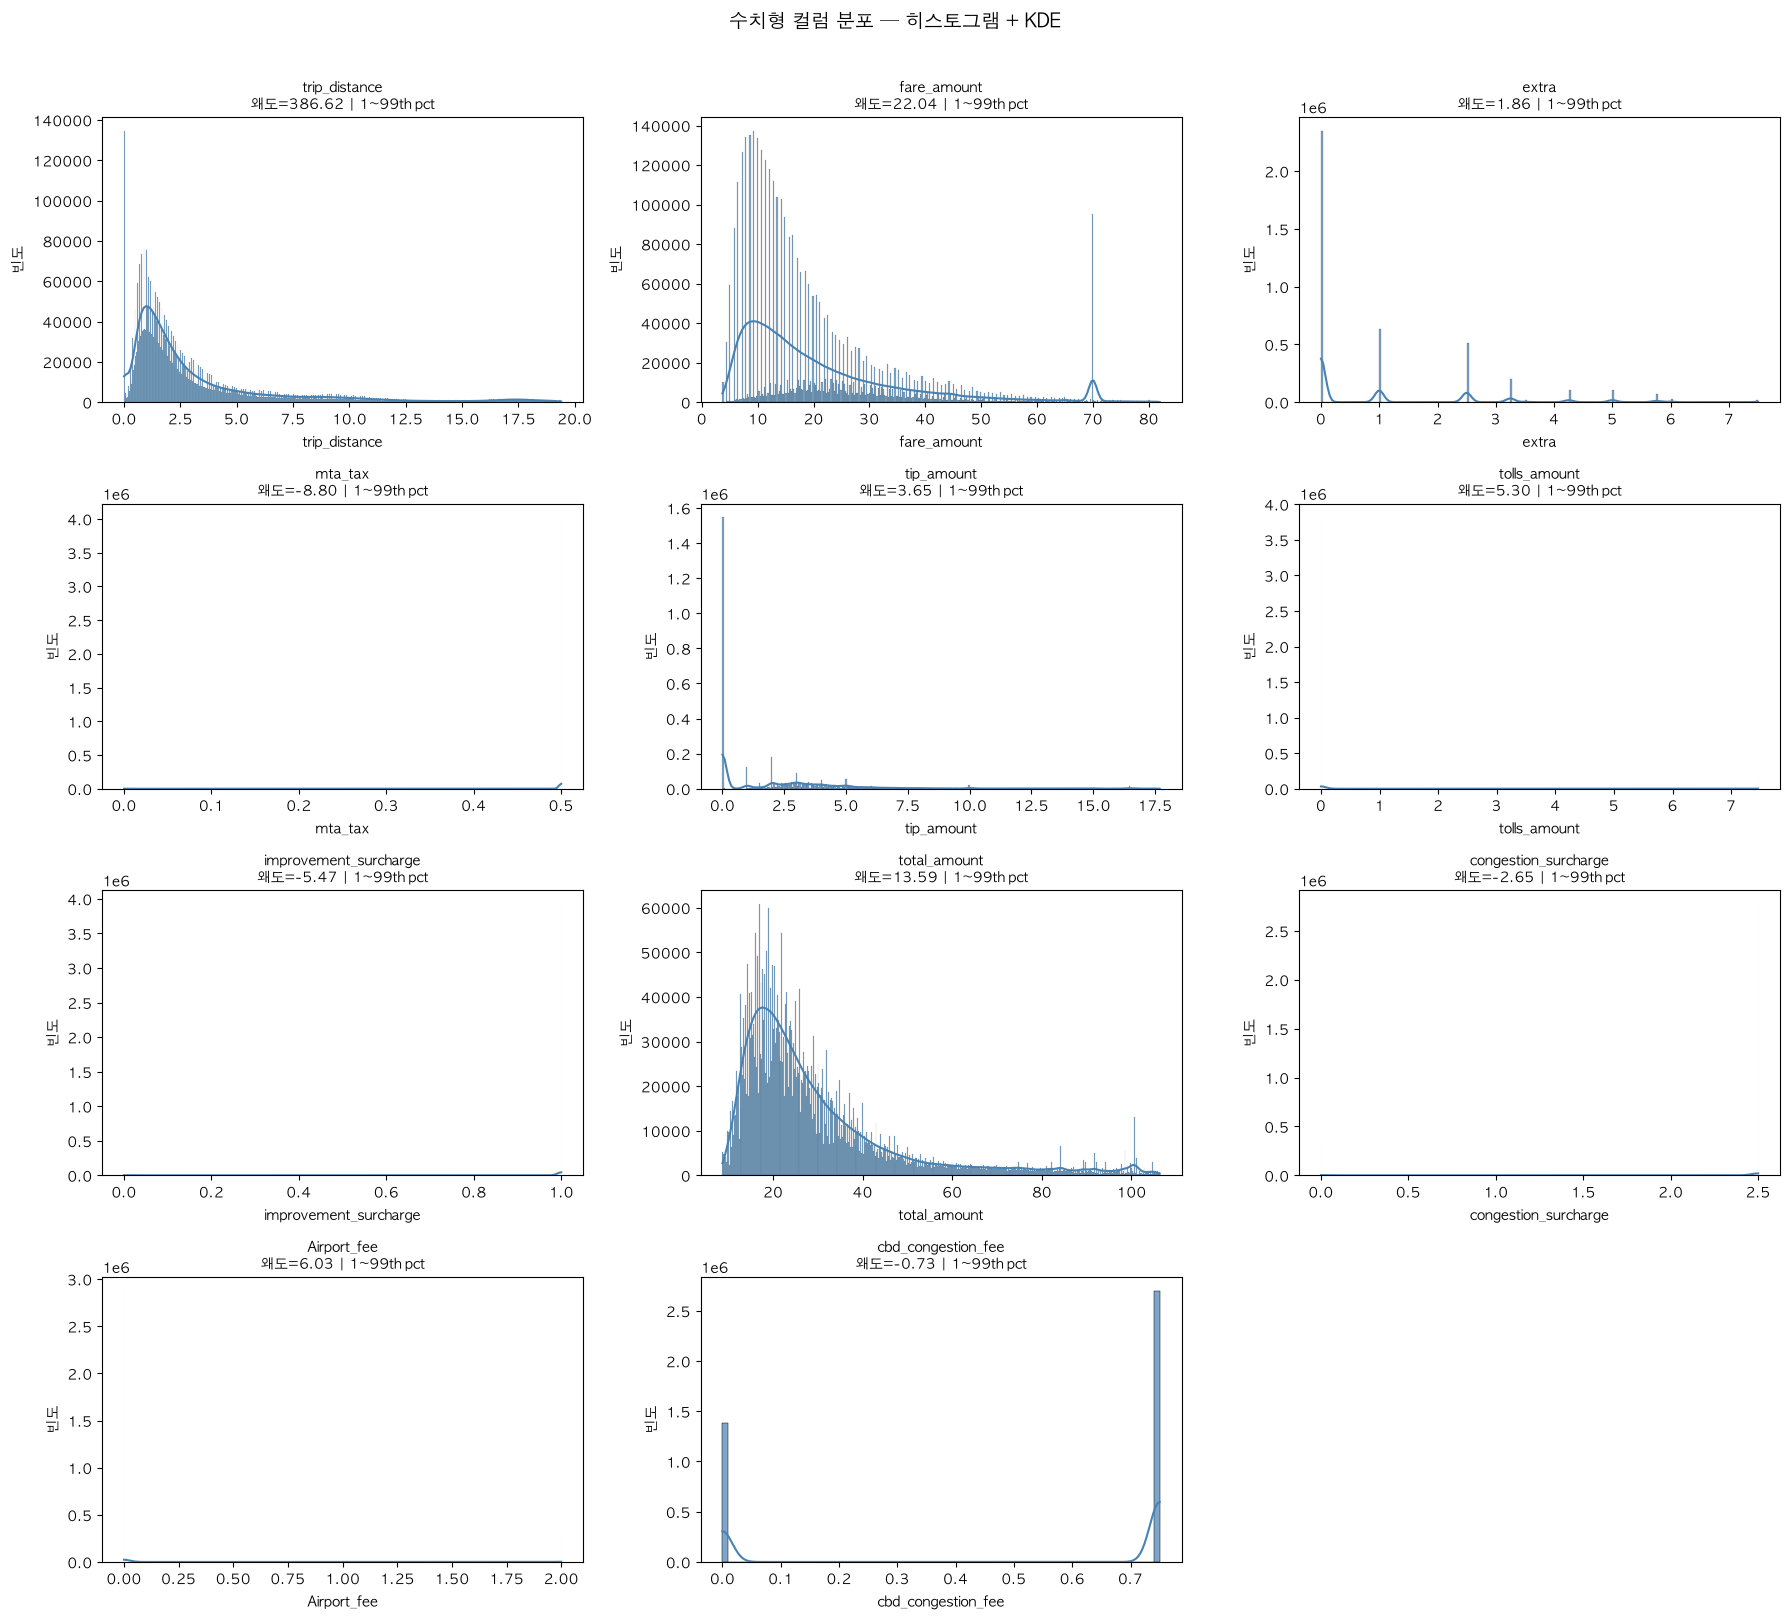


[강의자료 Think to look for — 수치형 분포]
  ✓ 이상점은 없는가?
  ✓ 분포 모양 — 종모양? 치우침? 봉우리 수?
  ✓ 히스토그램이 거칠다면 bin 수 조정 후 재확인


In [16]:
n_c = 3; n_r = math.ceil(len(numeric_cols)/n_c)
fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = pdf[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    data_c = data[(data>=p1)&(data<=p99)]
    skew_v = data.skew()
    sns.histplot(data_c, kde=True, ax=ax, color="steelblue", alpha=0.7)
    ax.set_title(f"{col}\n왜도={skew_v:.2f} | 1~99th pct", fontsize=10)
    ax.set_xlabel(col); ax.set_ylabel("빈도")

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
fig.suptitle("수치형 컬럼 분포 — 히스토그램 + KDE", fontsize=14, y=1.01)
plt.tight_layout()
save_fig(fig, "11_numeric_histograms.png")
plt.show(); plt.close(fig)

print("\n[강의자료 Think to look for — 수치형 분포]")
print("  ✓ 이상점은 없는가?")
print("  ✓ 분포 모양 — 종모양? 치우침? 봉우리 수?")
print("  ✓ 히스토그램이 거칠다면 bin 수 조정 후 재확인")

---
## Part 12. 수치형 이상치 — 박스플롯 (IQR)
> 강의자료 p.39 IQR Based Outlier Detection

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/12_numeric_boxplots.png


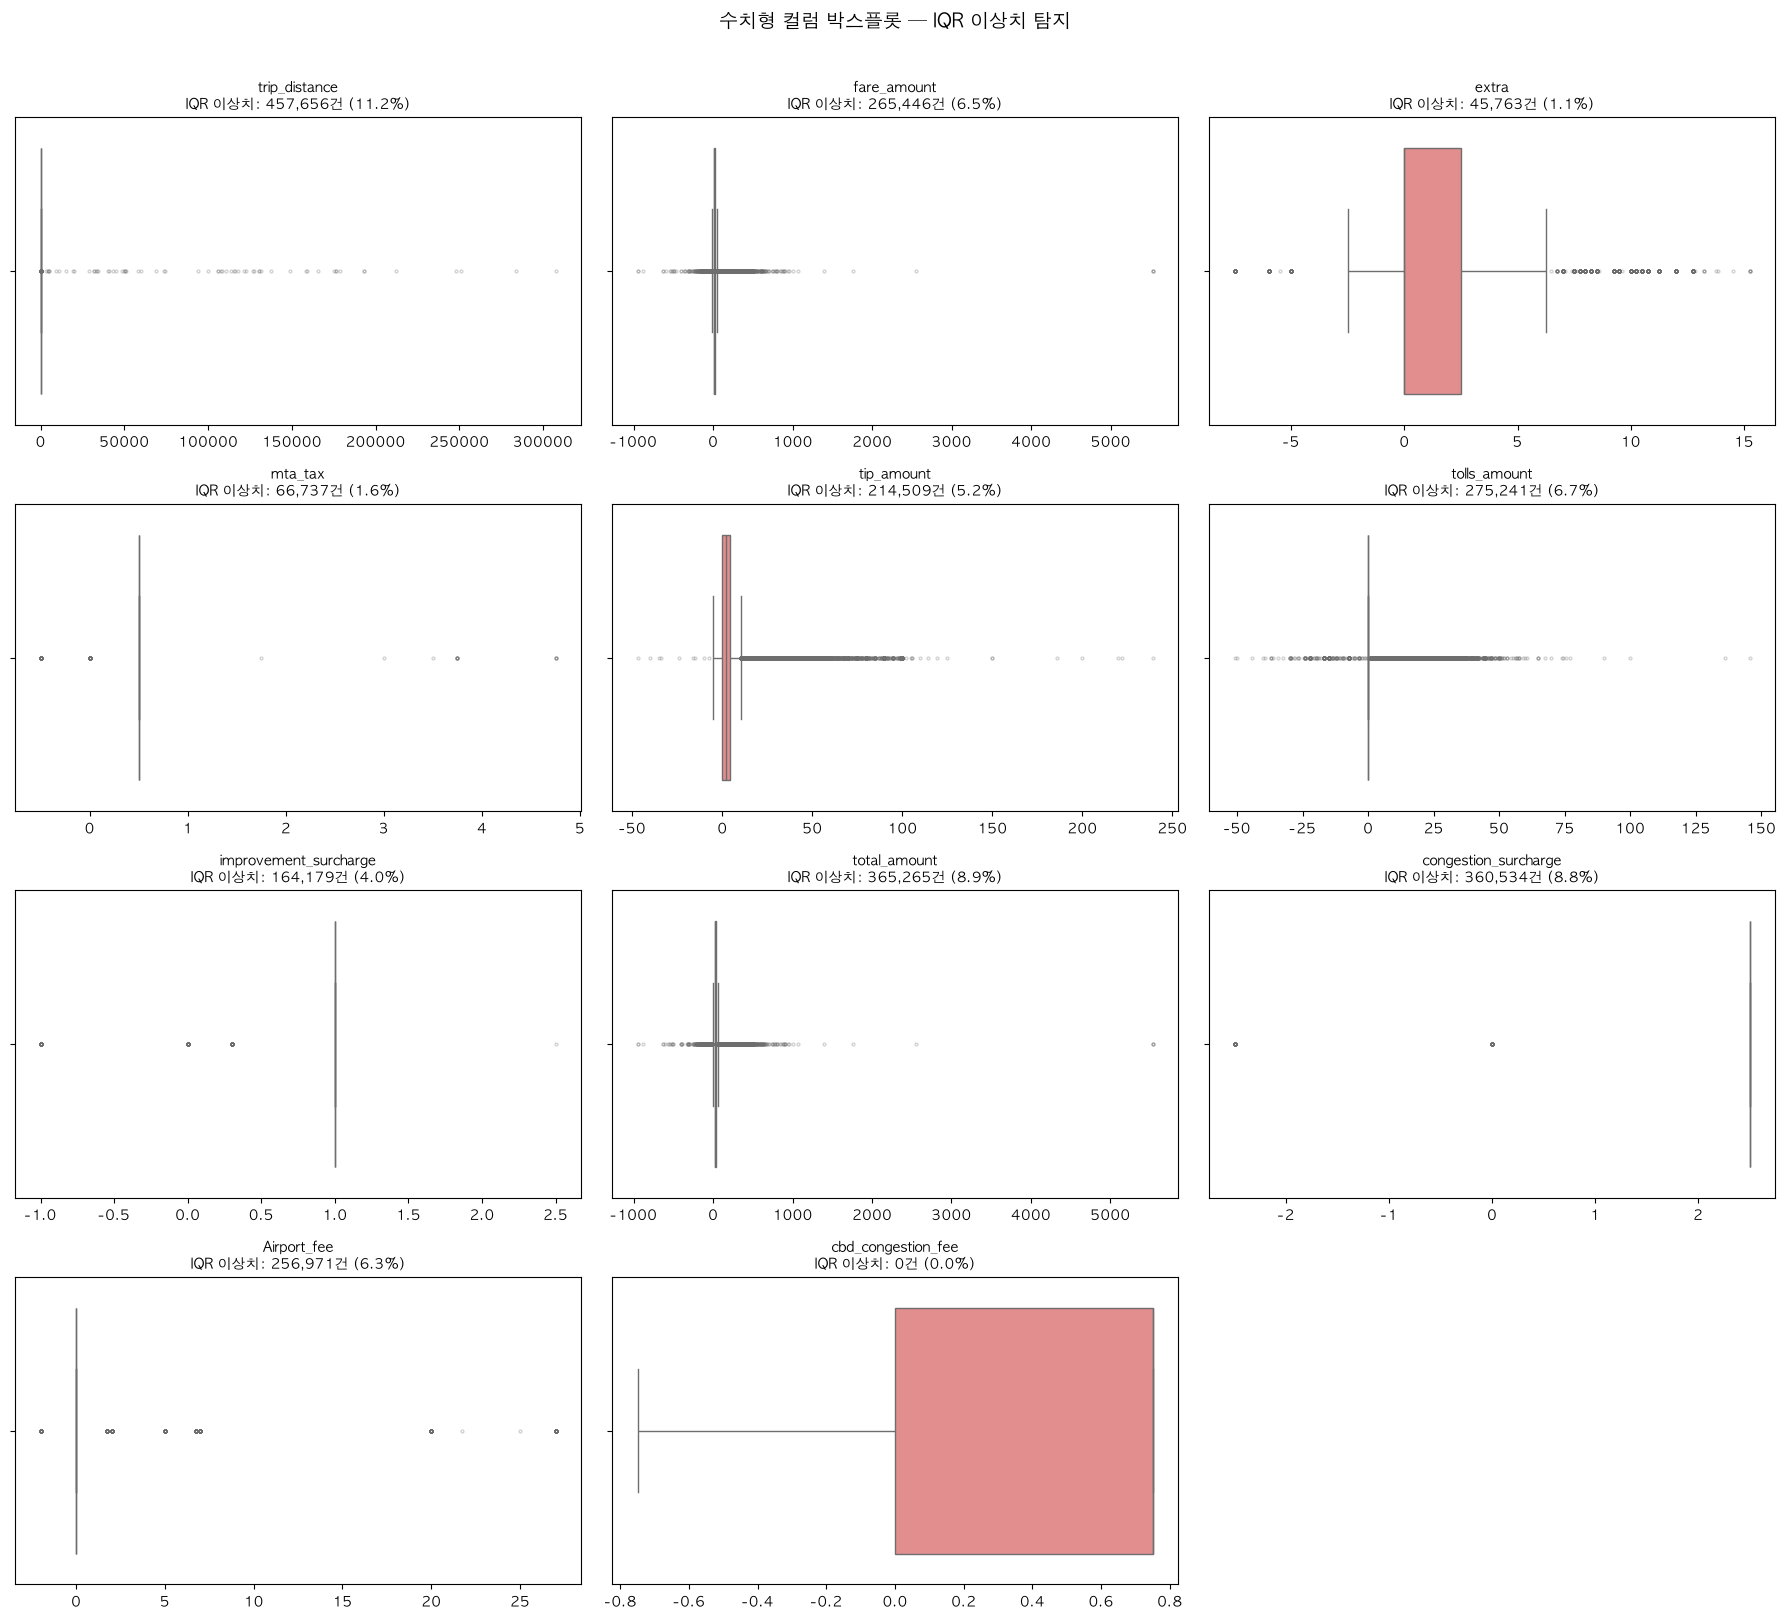


[강의자료 Think to look for — 이상치]
  ✓ 도메인에 따라 이상치가 중요 의미일 수 있음 (공항 고정요금 등)
  ✓ 입력 오류/에러값이 Outlier로 인식될 수 있음
  ✓ 무조건적 제거 위험 → 발생 원인 고찰 필요


In [17]:
n_c = 3; n_r = math.ceil(len(numeric_cols)/n_c)
fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(x=pdf[col], ax=ax, color="lightcoral",
                flierprops=dict(markersize=2, alpha=0.3))
    q1, q3 = pdf[col].quantile(0.25), pdf[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((pdf[col]<q1-1.5*iqr)|(pdf[col]>q3+1.5*iqr)).sum()
    ax.set_title(f"{col}\nIQR 이상치: {n_out:,}건 ({n_out/len(pdf)*100:.1f}%)", fontsize=10)
    ax.set_xlabel("")

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
fig.suptitle("수치형 컬럼 박스플롯 — IQR 이상치 탐지", fontsize=14, y=1.01)
plt.tight_layout()
save_fig(fig, "12_numeric_boxplots.png")
plt.show(); plt.close(fig)

print("\n[강의자료 Think to look for — 이상치]")
print("  ✓ 도메인에 따라 이상치가 중요 의미일 수 있음 (공항 고정요금 등)")
print("  ✓ 입력 오류/에러값이 Outlier로 인식될 수 있음")
print("  ✓ 무조건적 제거 위험 → 발생 원인 고찰 필요")

---
## Part 13. 수치형 vs 수치형 — 상관관계 히트맵
> 강의자료 p.25 변수 간 상관관계 탐색

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/13_correlation_heatmap.png


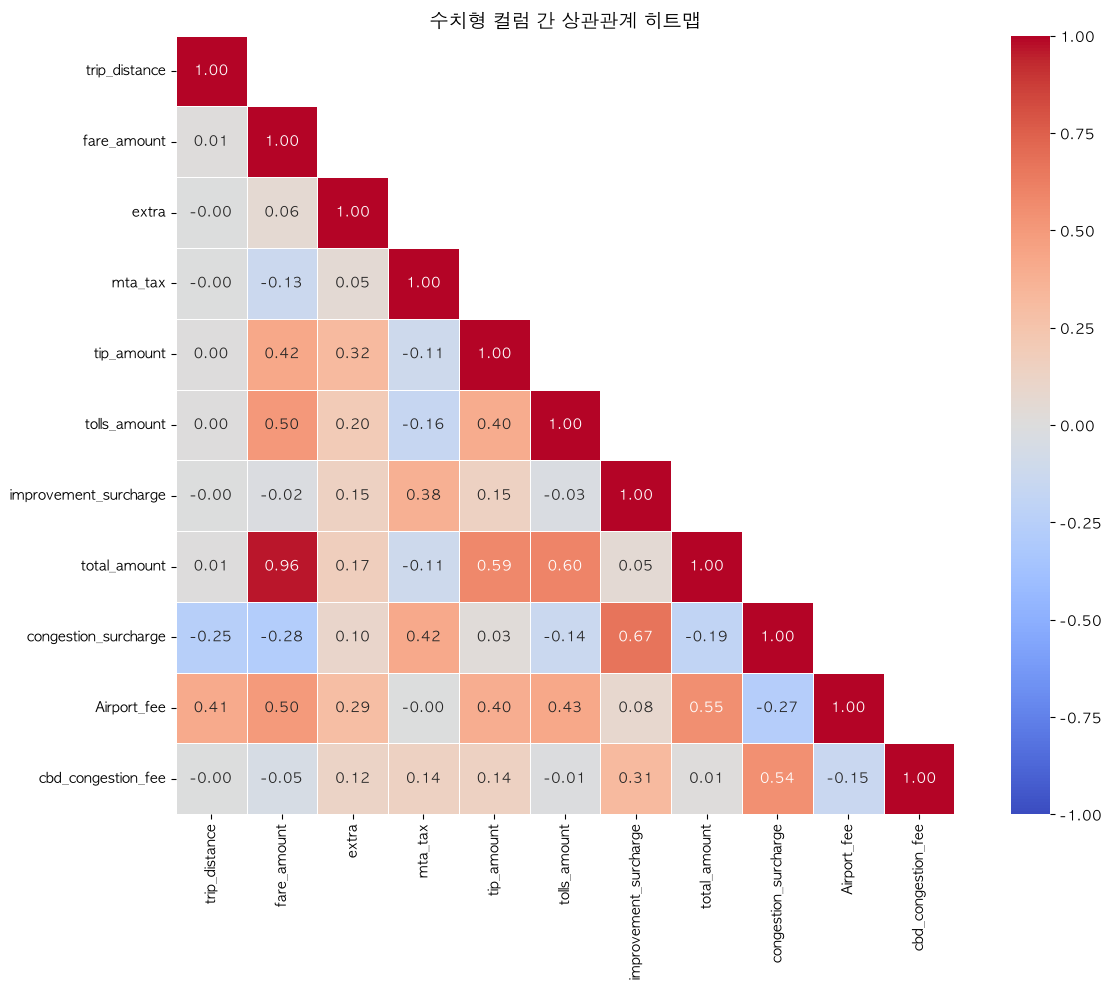


[상관계수 |r|>0.7 쌍 — 다중공선성 후보]


,변수1,변수2,상관계수
22,total_amount,fare_amount,0.963367



[강의자료 Think to look for — 상관관계]
  ✓ 가장 강한 상관관계를 가지는 변수는?
  ✓ 서로 비슷한 정보 가진 변수 → 변수 제거, 다중공선성 검토


In [18]:
corr = pdf[numeric_cols].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, mask=mask, ax=ax,
            linewidths=0.5, square=True)
ax.set_title("수치형 컬럼 간 상관관계 히트맵", fontsize=14)
plt.tight_layout()
save_fig(fig, "13_correlation_heatmap.png")
plt.show(); plt.close(fig)

print("\n[상관계수 |r|>0.7 쌍 — 다중공선성 후보]")
high_corr = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack().reset_index()
)
high_corr.columns = ["변수1","변수2","상관계수"]
display(high_corr[high_corr["상관계수"].abs()>0.7]
        .sort_values("상관계수", ascending=False))

print("\n[강의자료 Think to look for — 상관관계]")
print("  ✓ 가장 강한 상관관계를 가지는 변수는?")
print("  ✓ 서로 비슷한 정보 가진 변수 → 변수 제거, 다중공선성 검토")

---
## Part 14. 수치형 vs 수치형 — 산점도
> 강의자료 p.28 Quantitative vs Quantitative 살펴보기

In [19]:
scatter_df = pdf[
    (pdf["trip_distance"]>0)&(pdf["trip_distance"]<50)&
    (pdf["fare_amount"]>0)&(pdf["fare_amount"]<200)
].copy()
scatter_df["rate_label"] = scatter_df["RatecodeID"].map(LABEL_MAP["RatecodeID"]).fillna("기타")
sample_df = scatter_df.sample(min(30_000, len(scatter_df)), random_state=42)

fig = px.scatter(
    sample_df, x="trip_distance", y="fare_amount",
    color="rate_label",
    title="trip_distance vs fare_amount (요금 유형별 색 구분, 최대 3만건)",
    labels={"trip_distance":"이동 거리(마일)","fare_amount":"기본 요금($)","rate_label":"요금 유형"},
    opacity=0.4, color_discrete_sequence=px.colors.qualitative.Set1,
)
save_fig(fig, "14_scatter_distance_fare.png")
fig.show()

print("\n[강의자료 Think to look for — 산점도]")
print("  ✓ 선형 vs 비선형 관계?")
print("  ✓ 관계 강도는 강한가 약한가?")
print("  ✓ 이상점이 있는가? 로그변환 필요한가?")
print("  ✓ 인과관계 존재? 원인=X, 결과=Y")
print("  ✓ 데이터 너무 많으면 Sampling + alpha 옵션으로 반투명")
print("  → JFK(RatecodeID=2): fare≈70 고정, 거리와 무관")

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/14_scatter_distance_fare.png



[강의자료 Think to look for — 산점도]
  ✓ 선형 vs 비선형 관계?
  ✓ 관계 강도는 강한가 약한가?
  ✓ 이상점이 있는가? 로그변환 필요한가?
  ✓ 인과관계 존재? 원인=X, 결과=Y
  ✓ 데이터 너무 많으면 Sampling + alpha 옵션으로 반투명
  → JFK(RatecodeID=2): fare≈70 고정, 거리와 무관


---
## Part 15. 수치형 vs 범주형 — 그룹별 박스플롯
> 강의자료 p.29 Quantitative vs Categorical

/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn/T/ipykernel_88974/3895217992.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=cat_col, y=num_col, order=order,


/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn/T/ipykernel_88974/3895217992.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=cat_col, y=num_col, order=order,


/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn/T/ipykernel_88974/3895217992.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=cat_col, y=num_col, order=order,


/var/folders/4r/b10737c53tnbwwv3g61wk0s40000gn/T/ipykernel_88974/3895217992.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=cat_col, y=num_col, order=order,


저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/15_quant_vs_cat_boxplot.png


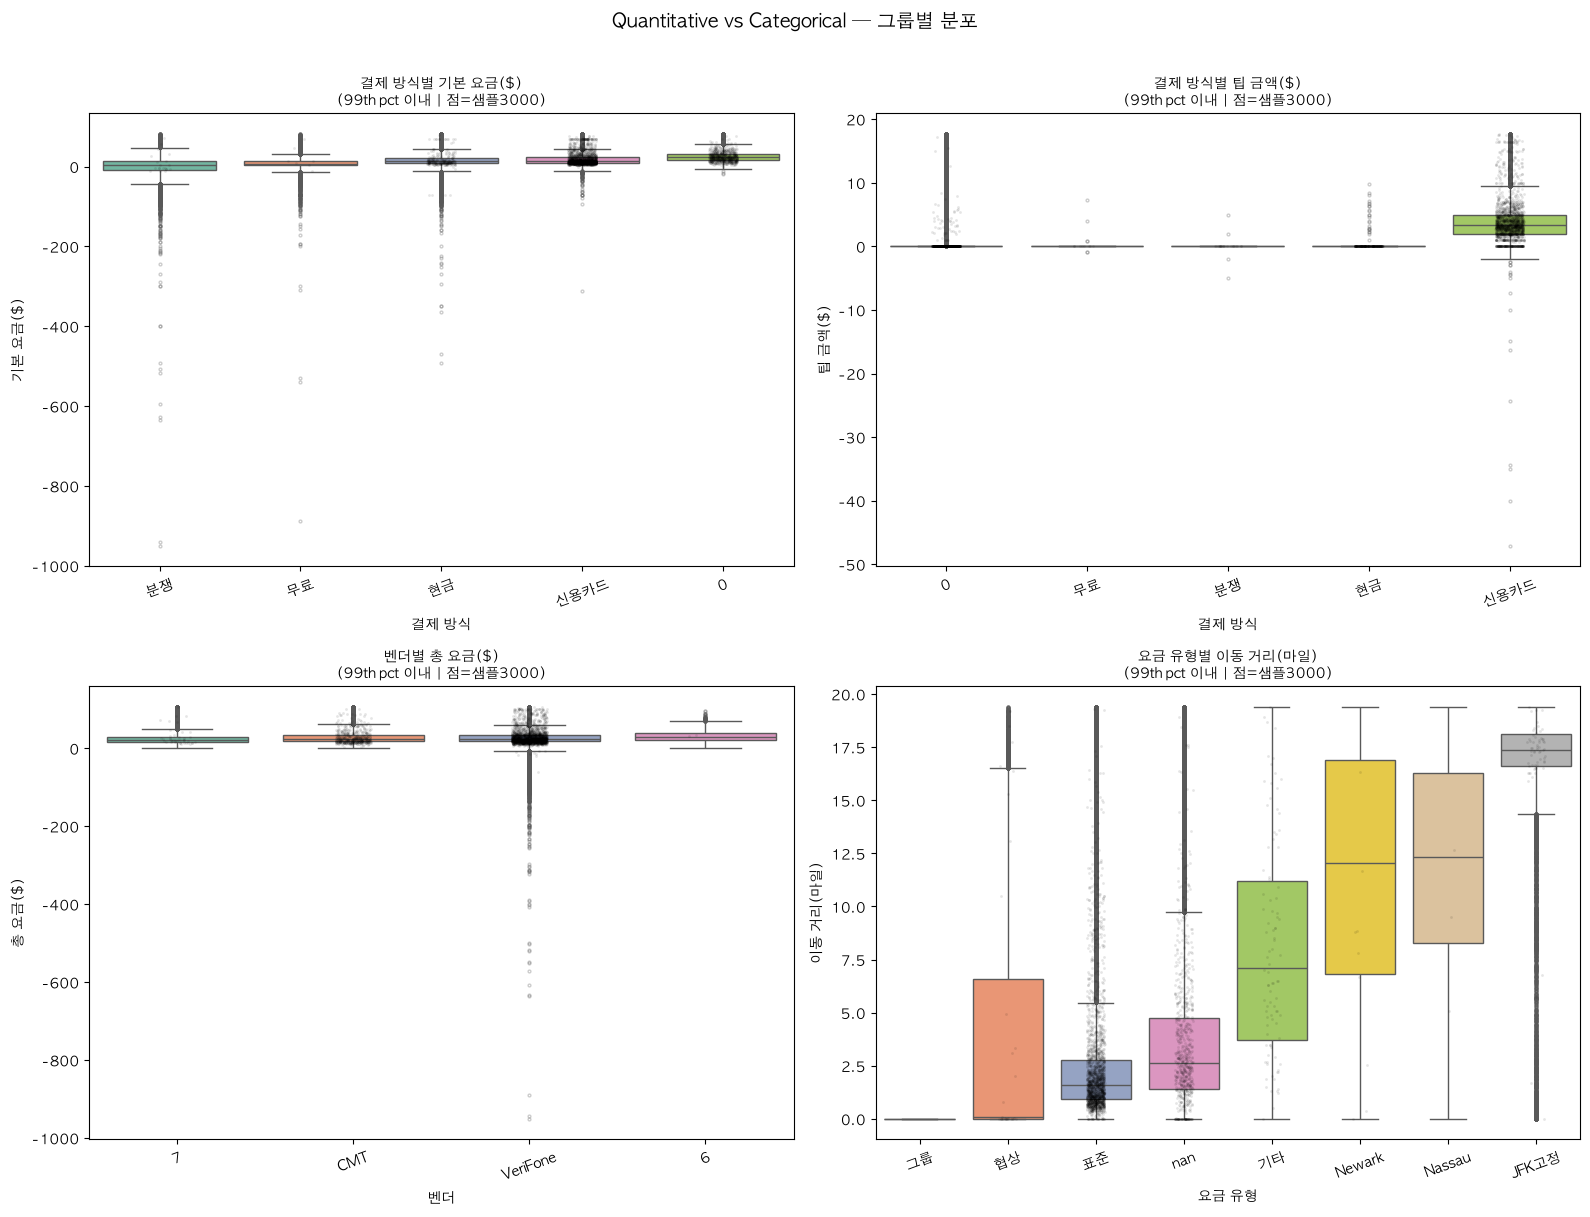


[강의자료 Think to look for — Quant vs Categorical]
  ✓ Class별 이상치는 있는가?
  ✓ Class별 관측치는 충분한가? (점표시+반투명 확인)
  ✓ Class의 적절한 순서가 있는가?
  ✓ 로그변환 / 축 교환 필요한가?
  → 현금 결제: tip_amount≈0 → is_cash 파생변수 필요


In [20]:
pairs = [
    ("payment_type", "fare_amount",   "결제 방식","기본 요금($)"),
    ("payment_type", "tip_amount",    "결제 방식","팁 금액($)"),
    ("VendorID",     "total_amount",  "벤더",    "총 요금($)"),
    ("RatecodeID",   "trip_distance", "요금 유형","이동 거리(마일)"),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (cat_col, num_col, xl, yl) in enumerate(pairs):
    ax = axes[i]
    plot_df = pdf[[cat_col, num_col]].copy()
    if cat_col in LABEL_MAP:
        plot_df[cat_col] = plot_df[cat_col].map(LABEL_MAP[cat_col]).fillna(plot_df[cat_col].astype(str))
    p99 = plot_df[num_col].quantile(0.99)
    plot_df = plot_df[plot_df[num_col] <= p99]
    order = plot_df.groupby(cat_col)[num_col].median().sort_values().index

    sns.boxplot(data=plot_df, x=cat_col, y=num_col, order=order,
                ax=ax, palette="Set2", flierprops=dict(markersize=2, alpha=0.3))
    # 강의자료 권장: 점표시 + 반투명
    sns.stripplot(data=plot_df.sample(min(3000,len(plot_df)),random_state=42),
                  x=cat_col, y=num_col, order=order, ax=ax,
                  color="black", alpha=0.1, size=2)
    ax.set_title(f"{xl}별 {yl}\n(99th pct 이내 | 점=샘플3000)", fontsize=10)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Quantitative vs Categorical — 그룹별 분포", fontsize=14, y=1.01)
plt.tight_layout()
save_fig(fig, "15_quant_vs_cat_boxplot.png")
plt.show(); plt.close(fig)

print("\n[강의자료 Think to look for — Quant vs Categorical]")
print("  ✓ Class별 이상치는 있는가?")
print("  ✓ Class별 관측치는 충분한가? (점표시+반투명 확인)")
print("  ✓ Class의 적절한 순서가 있는가?")
print("  ✓ 로그변환 / 축 교환 필요한가?")
print("  → 현금 결제: tip_amount≈0 → is_cash 파생변수 필요")

---
## Part 16. 핵심 인사이트 시각화
> Question-driven EDA (강의자료 p.31)

In [21]:
# Q1. 시간대별 트립 수
hour_df = pdf.copy()
hour_df["hour"] = hour_df["tpep_pickup_datetime"].dt.hour
hc = hour_df["hour"].value_counts().sort_index().reset_index()
hc.columns = ["hour","trip_count"]
fig = px.bar(hc, x="hour", y="trip_count",
             title="Q1. 시간대별 트립 수 — 러시아워 패턴",
             labels={"hour":"승차 시간대","trip_count":"트립 수"},
             color="trip_count", color_continuous_scale="Blues")
fig.update_layout(coloraxis_showscale=False)
save_fig(fig, "16a_trips_by_hour.png")
fig.show()
print("→ is_rush_hour 파생변수: 7~9시, 17~19시")

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/16a_trips_by_hour.png


→ is_rush_hour 파생변수: 7~9시, 17~19시


In [22]:
# Q2. payment_type별 tip 분포
tip_df = pdf.copy()
tip_df["payment_label"] = tip_df["payment_type"].map(LABEL_MAP["payment_type"]).fillna("기타")
tip_sample = tip_df[tip_df["tip_amount"]>=0].sample(min(50_000, len(tip_df)), random_state=42)
fig = px.box(
    tip_sample,
    x="payment_label", y="tip_amount",
    title="Q2. 결제 방식별 팁 금액 분포 (5만건 샘플)",
    labels={"payment_label":"결제 방식","tip_amount":"팁($)"},
    color="payment_label",
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.update_layout(showlegend=False, yaxis_range=[0, 20])
save_fig(fig, "16b_tip_by_payment.png")
fig.show()
print("→ 현금 결제: tip거의 0 → 팁 분석 시 신용카드(=1)만 사용")

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/16b_tip_by_payment.png


→ 현금 결제: tip거의 0 → 팁 분석 시 신용카드(=1)만 사용


In [23]:
# Q3. 요일별 트립 수
dow_df = pdf.copy()
dow_df["weekday"] = dow_df["tpep_pickup_datetime"].dt.dayofweek
dow_labels = {0:"월",1:"화",2:"수",3:"목",4:"금",5:"토",6:"일"}
dow_df["weekday_label"] = dow_df["weekday"].map(dow_labels)
dc = dow_df["weekday_label"].value_counts().reindex(["월","화","수","목","금","토","일"]).reset_index()
dc.columns = ["weekday","count"]
fig = px.bar(dc, x="weekday", y="count",
             title="Q3. 요일별 트립 수",
             labels={"weekday":"요일","count":"트립 수"},
             color="count", color_continuous_scale="Greens")
fig.update_layout(coloraxis_showscale=False)
save_fig(fig, "16c_trips_by_weekday.png")
fig.show()
print("→ weekday / is_weekend 파생변수 제안")

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/16c_trips_by_weekday.png


→ weekday / is_weekend 파생변수 제안


---
## Part 17. Borough 위치 분석

In [24]:
borough_df = (
    mapped.groupby("PU_Borough",observed=True)
    .agg(trips=("total_amount","count"),avg_total=("total_amount","mean"))
    .reset_index().sort_values("trips",ascending=False)
)
fig = make_subplots(rows=1,cols=2,
                    subplot_titles=("Borough별 트립 수","Borough별 평균 total_amount($)"))
fig.add_trace(go.Bar(x=borough_df["PU_Borough"],y=borough_df["trips"],
                     marker_color="steelblue",name="트립 수"),row=1,col=1)
fig.add_trace(go.Bar(x=borough_df["PU_Borough"],y=borough_df["avg_total"].round(2),
                     marker_color="coral",name="평균 요금"),row=1,col=2)
fig.update_layout(title_text="Borough별 분석",showlegend=False,height=450)
save_fig(fig,"17_borough_analysis.png")
fig.show()

top_zones = mapped["PU_Zone"].value_counts().head(10).reset_index()
top_zones.columns = ["Zone","count"]
fig2 = px.bar(top_zones.sort_values("count"),x="count",y="Zone",orientation="h",
              title="픽업 트립 수 상위 10 Zone",
              labels={"count":"트립 수","Zone":"Zone"},
              color="count",color_continuous_scale="Blues")
fig2.update_layout(coloraxis_showscale=False)
save_fig(fig2,"17_top_zones.png")
fig2.show()

저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/17_borough_analysis.png


저장: /Users/roh-eunseo/SKALA/code/python/0804/day2-data-analysis/output/17_top_zones.png


---
## Part 18. 관찰 정리 — 팀원 인계 메모

### 📌 EDA Findings (강의자료 p.13 기준)

| 질문 | 분석 | 발견 | Next Action |
|------|------|------|-------------|
| 결측치는 어디에? | isnull().sum() | 원본 그대로 존재 (미정제) | 정제 전략 수립 필요 |
| 중복은? | duplicated() | 원본 그대로 존재 (미정제) | 정제 전략 수립 필요 |
| 수치형 분포는? | 히스토그램+왜도 | trip_distance 등 오른쪽 치우침 | 로그변환 검토 |
| 이상치는? | IQR 박스플롯 | total_amount 음수, 소요시간 음수 | 이상치 처리 |
| 범주형 구성은? | value_counts | 신용카드 70%+ | 클래스 불균형 확인 |
| 비슷한 변수는? | 상관관계 히트맵 | fare ↔ total 강상관 | 다중공선성 검토 |

### 🛠 파생변수 제안 (강의자료 p.72 Feature Creation Strategies)

```python
# Transform Features — 날짜에서 시간 정보 추출
df['duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60
df['hour']         = df['tpep_pickup_datetime'].dt.hour
df['weekday']      = df['tpep_pickup_datetime'].dt.dayofweek
df['is_weekend']   = df['weekday'].isin([5,6]).astype(int)

# Combine Features — 비율/차이
df['is_rush_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_airport']   = df['RatecodeID'].isin([2,3]).astype(int)
df['is_cash']      = (df['payment_type']==2).astype(int)
df['tip_rate']     = df['tip_amount'] / df['fare_amount'].replace(0, float('nan'))
df['speed_mph']    = df['trip_distance'] / (df['duration_min']/60).replace(0, float('nan'))

# Transform Features — 구간화 (Binning)
df['fare_bin'] = pd.cut(df['fare_amount'], bins=[0,10,20,30,50,200],
                         labels=['~10','10~20','20~30','30~50','50+'])
```

### 📐 통계검정 제안

| 검정 | 가설 |
|------|------|
| t-test | 러시아워 vs 비러시아워 fare_amount 평균 차이 |
| ANOVA | Borough별 total_amount 평균 차이 |
| 카이제곱 | payment_type ↔ RatecodeID 독립성 |
| Pearson/Spearman | trip_distance ↔ fare_amount 상관계수 |
| 회귀분석 | total_amount 예측 모델 |